# Analyse du trafic annuel entrant — Réseau ferré RATP

**Objectif** : identifier les stations les plus fréquentées du réseau RATP et analyser la distribution du trafic entrant sur l'ensemble du réseau.

**Source des données** : [Open Data RATP](https://data.ratp.fr/explore/dataset/trafic-annuel-entrant-par-station-du-reseau-ferre-2021/export/) — trafic annuel entrant par station, réseau ferré (métro + RER).

**Méthodologie** : nettoyage des données, analyse exploratoire (EDA), visualisations, extraction d'insights.

## 1. Import des librairies et chargement des données

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Le fichier exporté par data.ratp.fr utilise généralement le point-virgule comme séparateur.
df = pd.read_csv("data/trafic_ratp_2021.csv", sep=";")

print(f"Dimensions du dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head()

Dimensions du dataset : 371 lignes, 11 colonnes


,Rang,Réseau,Station,Trafic,Correspondance_1,Correspondance_2,Correspondance_3,Correspondance_4,Correspondance_5,Ville,Arrondissement pour Paris
0,1,Métro,GARE DU NORD,34503097,4,5,NaN,NaN,NaN,Paris,10.0
1,26,Métro,BARBES-ROCHECHOUART,5390939,2,4,NaN,NaN,NaN,Paris,18.0
2,63,Métro,GEORGE V,3842260,1,NaN,NaN,NaN,NaN,Paris,8.0
3,67,Métro,CONVENTION,3734750,12,NaN,NaN,NaN,NaN,Paris,15.0
4,84,Métro,CLICHY SAINT-OUEN,3420852,14,NaN,NaN,NaN,NaN,Saint-ouen,NaN


## 2. Inspection des colonnes

Le nom des colonnes peut varier légèrement selon le millésime du jeu de données. On les affiche pour identifier les colonnes utiles : nom de la station, réseau (métro/RER), et volume de trafic.

In [2]:
print(df.columns.tolist())
df.dtypes

['Rang', 'Réseau', 'Station', 'Trafic', 'Correspondance_1', 'Correspondance_2', 'Correspondance_3', 'Correspondance_4', 'Correspondance_5', 'Ville', 'Arrondissement pour Paris']


Rang                           int64
Réseau                           str
Station                          str
Trafic                         int64
Correspondance_1                 str
Correspondance_2                 str
Correspondance_3                 str
Correspondance_4             float64
Correspondance_5             float64
Ville                            str
Arrondissement pour Paris    float64
dtype: object

⚠️ **À adapter** : renseigne ci-dessous les noms exacts des colonnes affichées juste au-dessus (station, réseau, trafic). Exemple : `"Station"`, `"Reseau"`, `"Trafic"`.

In [3]:
COL_STATION = "Station"   # à adapter selon df.columns
COL_RESEAU = "Reseau"     # à adapter selon df.columns
COL_TRAFIC = "Trafic"     # à adapter selon df.columns

## 3. Nettoyage des données

In [4]:
# Valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df.isna().sum())

# Doublons
print(f"\nNombre de doublons : {df.duplicated().sum()}")

# Suppression des doublons éventuels
df = df.drop_duplicates()

# Conversion de la colonne trafic en numérique (certaines valeurs peuvent être des chaînes
# comme 'moins de 5' pour les comptages faibles avant 2022, à gérer si présentes)
df[COL_TRAFIC] = pd.to_numeric(df[COL_TRAFIC], errors="coerce")
df = df.dropna(subset=[COL_TRAFIC])

print(f"\nDimensions après nettoyage : {df.shape}")

Valeurs manquantes par colonne :
Rang                           0
Réseau                         0
Station                        0
Trafic                         0
Correspondance_1               0
Correspondance_2             310
Correspondance_3             354
Correspondance_4             366
Correspondance_5             368
Ville                          0
Arrondissement pour Paris    116
dtype: int64

Nombre de doublons : 0

Dimensions après nettoyage : (371, 11)


## 4. Analyse exploratoire (EDA)

In [5]:
df[COL_TRAFIC].describe()

count    3.710000e+02
mean     3.284427e+06
std      4.175318e+06
min      1.249410e+05
25%      1.532653e+06
50%      2.291843e+06
75%      3.556971e+06
max      3.450310e+07
Name: Trafic, dtype: float64

In [6]:
# Top 10 des stations les plus fréquentées
top10 = df.sort_values(COL_TRAFIC, ascending=False).head(10)
top10[[COL_STATION, COL_TRAFIC]]

,Station,Trafic
0,GARE DU NORD,34503097
288,SAINT-LAZARE,33128384
50,GARE DU NORD-RER,32102825
34,GARE DE LYON,28640475
192,GARE DE LYON-RER,27505309
258,CHATELET-LES HALLES-RER,24100383
260,MONTPARNASSE-BIENVENUE,20407224
22,LA DEFENSE-RER,17570475
302,NANTERRE-PREFECTURE,16665520
208,GARE DE L'EST,15538471


## 5. Visualisations

C:\Users\Shrimpy\AppData\Local\Temp\ipykernel_10992\2643574632.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x=COL_TRAFIC, y=COL_STATION, palette="viridis")


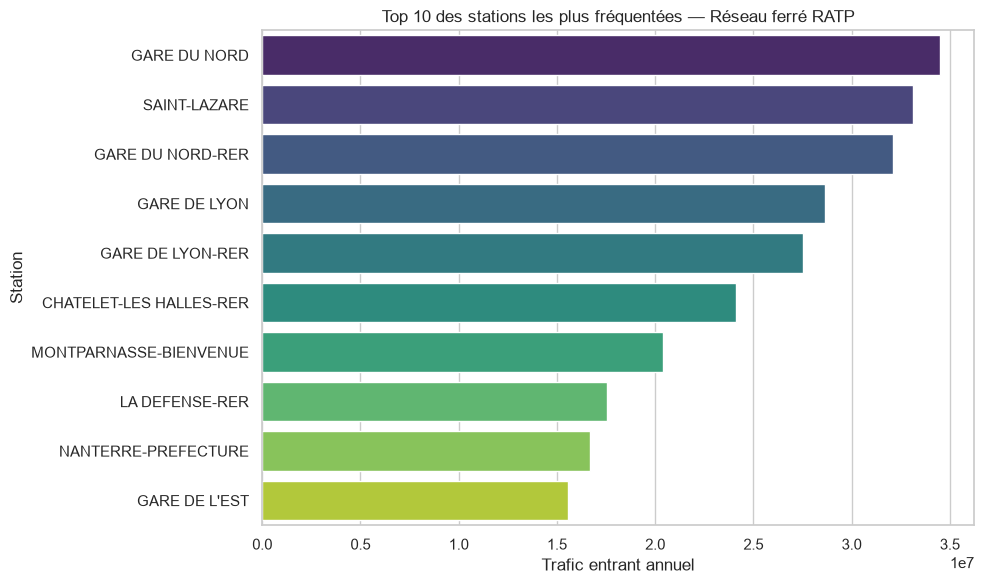

In [7]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top10, x=COL_TRAFIC, y=COL_STATION, palette="viridis")
plt.title("Top 10 des stations les plus fréquentées — Réseau ferré RATP")
plt.xlabel("Trafic entrant annuel")
plt.ylabel("Station")
plt.tight_layout()
plt.savefig("top10_stations.png", dpi=150)
plt.show()

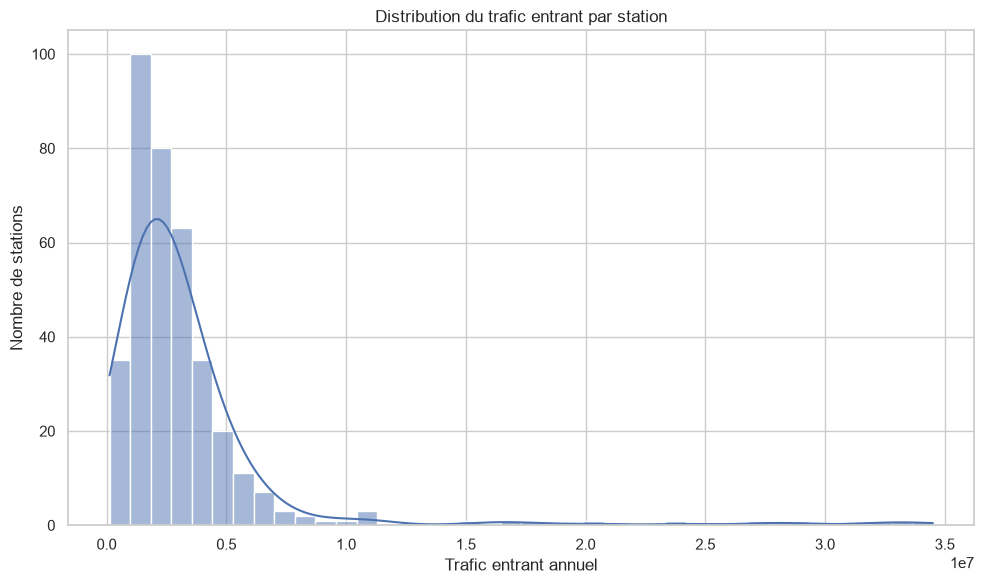

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df[COL_TRAFIC], bins=40, kde=True)
plt.title("Distribution du trafic entrant par station")
plt.xlabel("Trafic entrant annuel")
plt.ylabel("Nombre de stations")
plt.tight_layout()
plt.savefig("distribution_trafic.png", dpi=150)
plt.show()

In [9]:
# Si une colonne réseau (métro / RER) existe, comparaison des deux réseaux
if COL_RESEAU in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=COL_RESEAU, y=COL_TRAFIC)
    plt.title("Trafic entrant par type de réseau")
    plt.tight_layout()
    plt.savefig("trafic_par_reseau.png", dpi=150)
    plt.show()

## 6. Conclusion

*(À compléter une fois le notebook exécuté sur tes données)*

- Station la plus fréquentée : ...
- Écart entre la station n°1 et la médiane du réseau : ... % 
- Observation métro vs RER : ...
